#Primer Proyecto de ML



In [27]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

##Cargar los datos y analizarlos

In [28]:
data = pd.read_csv('/content/vehicle_emissions.csv')
data

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7
...,...,...,...,...,...,...,...,...,...,...,...,...
930,2021,Volvo,XC40 T5 AWD,SUV: Small,2.0,4,AS8,10.7,7.7,9.4,219,5
931,2021,Volvo,XC60 T5 AWD,SUV: Small,2.0,4,AS8,11.1,8.3,9.9,230,5
932,2021,Volvo,XC60 T6 AWD,SUV: Small,2.0,4,AS8,11.7,8.6,10.3,240,7
933,2021,Volvo,XC90 T5 AWD,SUV: Standard,2.0,4,AS8,11.5,8.4,10.1,236,5


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Model_Year                              935 non-null    int64  
 1   Make                                    935 non-null    object 
 2   Model                                   935 non-null    object 
 3   Vehicle_Class                           935 non-null    object 
 4   Engine_Size                             935 non-null    float64
 5   Cylinders                               935 non-null    int64  
 6   Transmission                            935 non-null    object 
 7   Fuel_Consumption_in_City(L/100 km)      935 non-null    float64
 8   Fuel_Consumption_in_City_Hwy(L/100 km)  935 non-null    float64
 9   Fuel_Consumption_comb(L/100km)          935 non-null    float64
 10  CO2_Emissions                           935 non-null    int64 

In [30]:
data.columns

Index(['Model_Year', 'Make', 'Model', 'Vehicle_Class', 'Engine_Size',
       'Cylinders', 'Transmission', 'Fuel_Consumption_in_City(L/100 km)',
       'Fuel_Consumption_in_City_Hwy(L/100 km)',
       'Fuel_Consumption_comb(L/100km)', 'CO2_Emissions', 'Smog_Level'],
      dtype='object')

In [31]:
data['Model_Year'].value_counts()

,count
Model_Year,
2021,935


In [32]:
for columns in data.columns:
  print(f'Conteo de valores de {columns}:\n{data[columns].value_counts()}\n')

Conteo de valores de Model_Year:
Model_Year
2021    935
Name: count, dtype: int64

Conteo de valores de Make:
Make
Ford             87
Chevrolet        84
Mercedes-Benz    72
Porsche          63
GMC              61
BMW              54
Toyota           49
Audi             43
Jeep             36
Mazda            29
Hyundai          27
Lexus            27
Kia              25
Honda            23
Cadillac         22
MINI             22
Nissan           22
Dodge            22
Volkswagen       16
Subaru           16
Ram              16
Volvo            13
Maserati         11
Rolls-Royce      10
Buick             9
Lamborghini       9
Genesis           8
Bentley           8
Lincoln           7
Acura             6
Aston Martin      6
Alfa Romeo        6
Chrysler          6
Jaguar            6
Infiniti          6
Mitsubishi        5
Bugatti           2
FIAT              1
Name: count, dtype: int64

Conteo de valores de Model:
Model
Sierra 4WD             7
Silverado 4WD          7
Sierra        

In [33]:
data.describe()

,Model_Year,Engine_Size,Cylinders,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
count,935.0,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000
mean,2021.0,3.214866,5.716578,12.498610,9.306203,11.060214,258.529412,4.726203
std,0.0,1.388513,1.977359,3.487271,2.215819,2.867028,64.442768,1.712127
min,2021.0,1.000000,3.000000,4.000000,3.900000,4.000000,94.000000,1.000000
25%,2021.0,2.000000,4.000000,10.100000,7.700000,9.100000,213.000000,3.000000
50%,2021.0,3.000000,6.000000,12.000000,9.000000,10.700000,255.000000,5.000000
75%,2021.0,4.000000,8.000000,14.800000,10.800000,13.100000,303.500000,6.000000
max,2021.0,8.000000,16.000000,30.300000,20.900000,26.100000,608.000000,7.000000


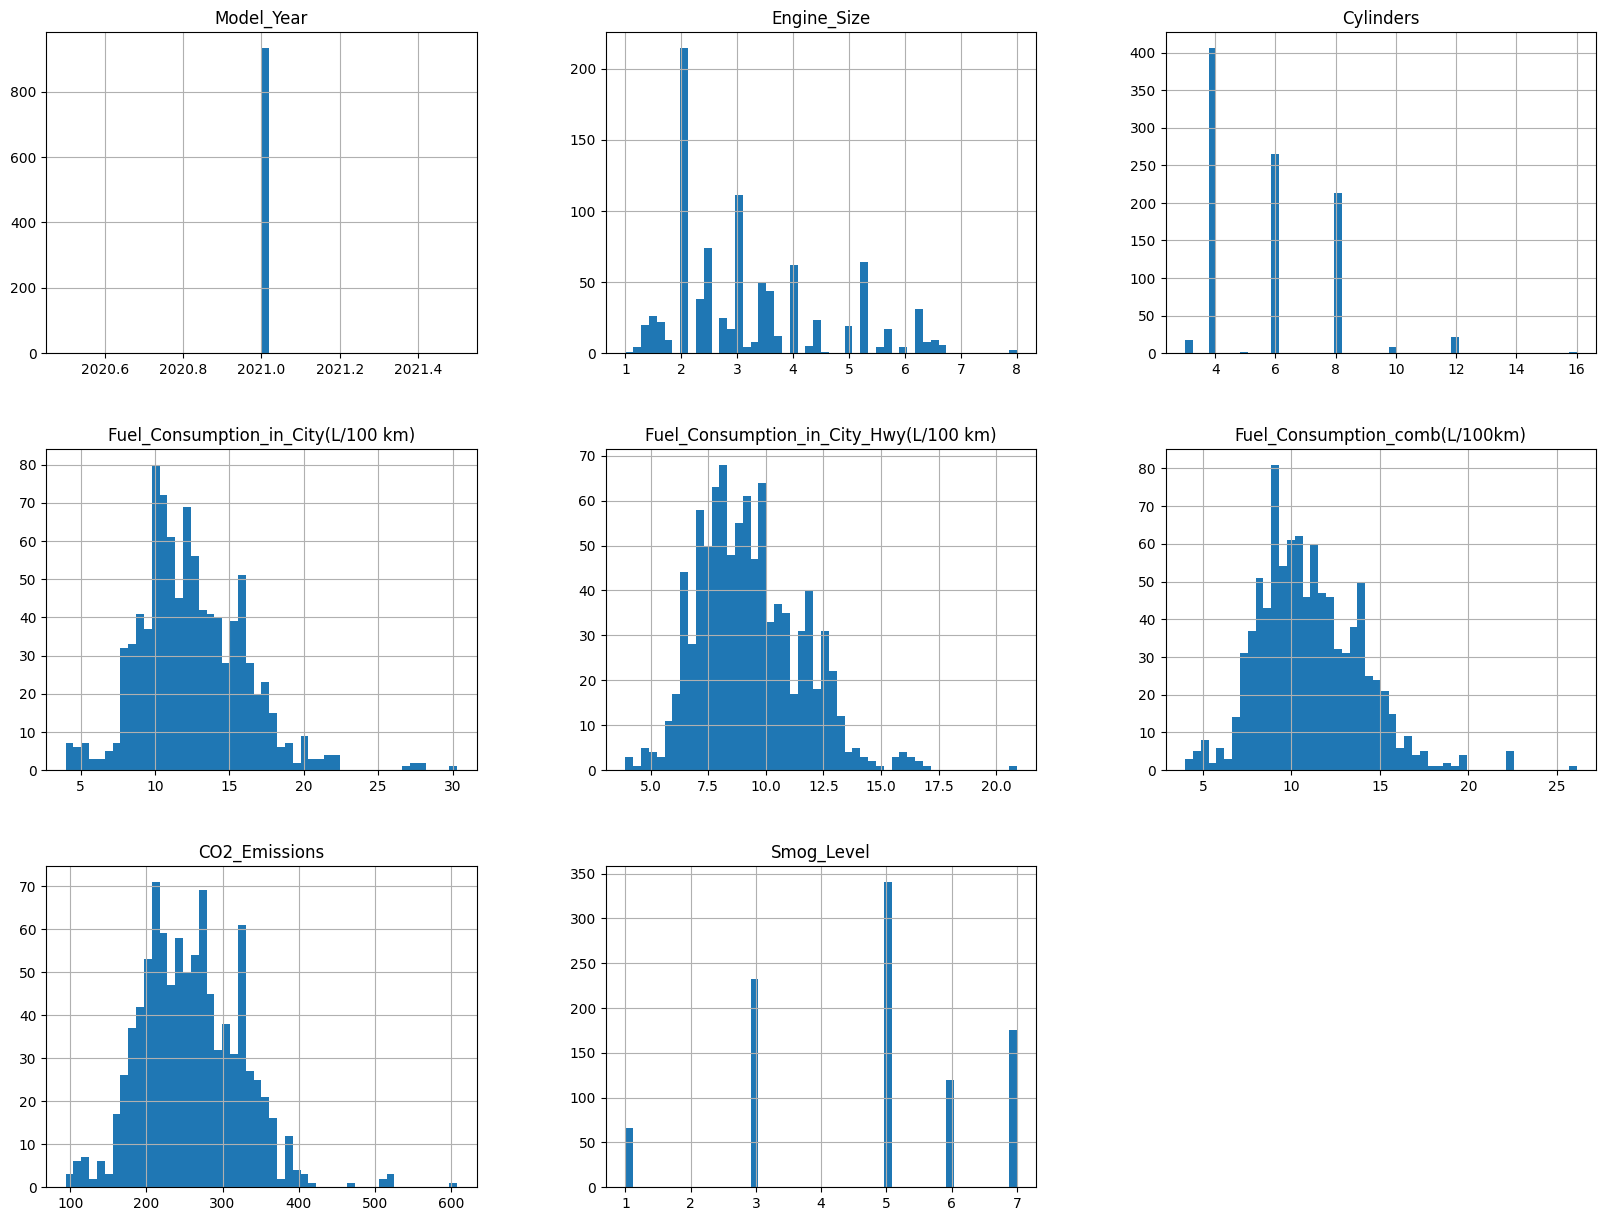

In [34]:
import matplotlib.pyplot as plt
data.hist(bins=50,figsize=(20,15))
plt.show()

<Axes: xlabel='Engine_Size', ylabel='CO2_Emissions'>

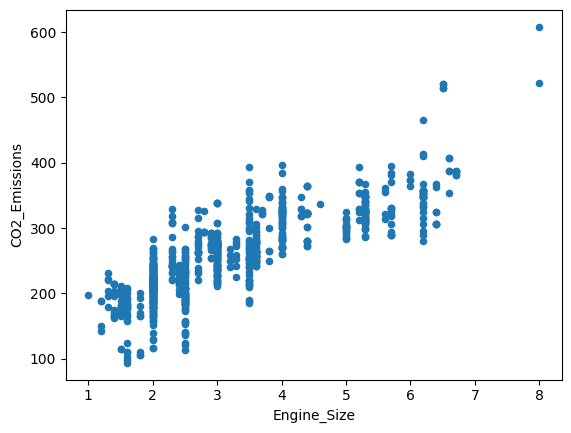

In [35]:
data.plot(kind='scatter',x='Engine_Size',y='CO2_Emissions')

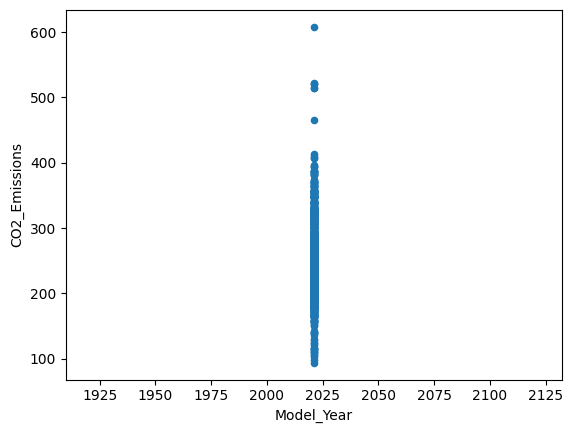

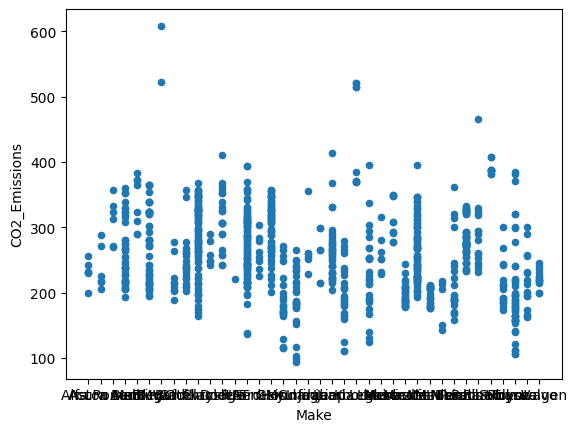

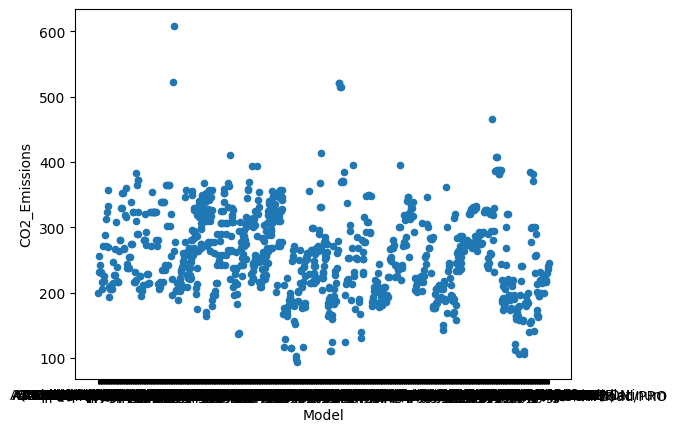

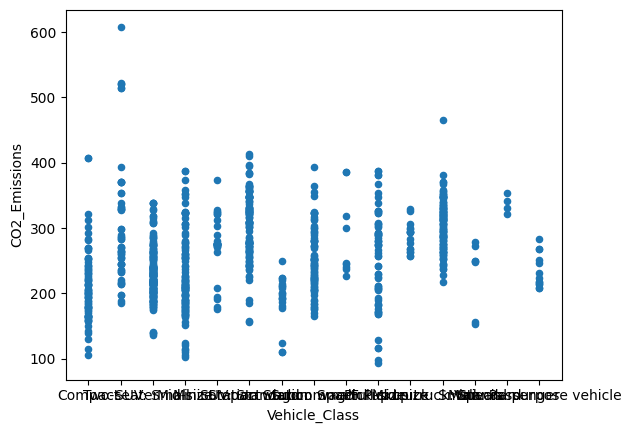

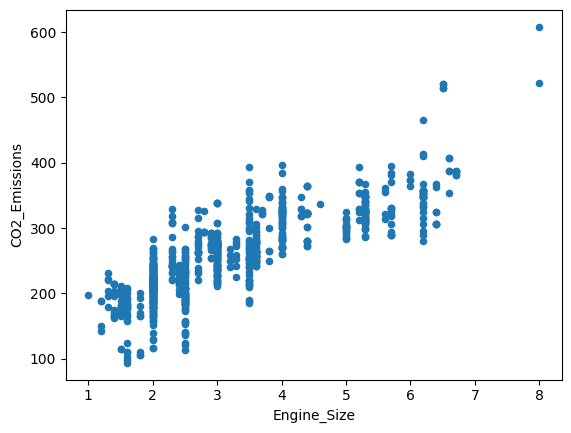

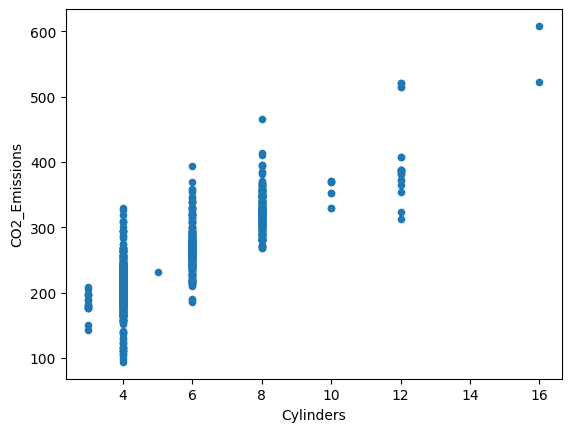

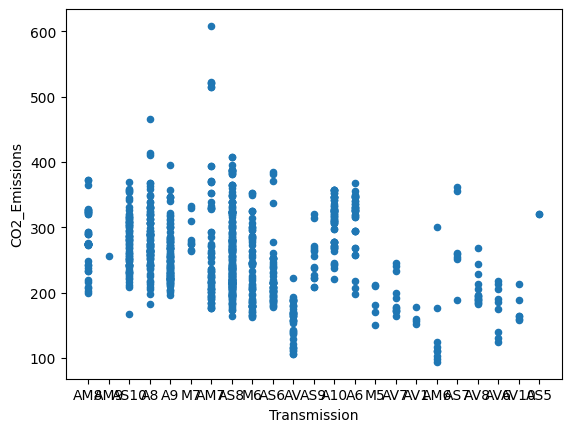

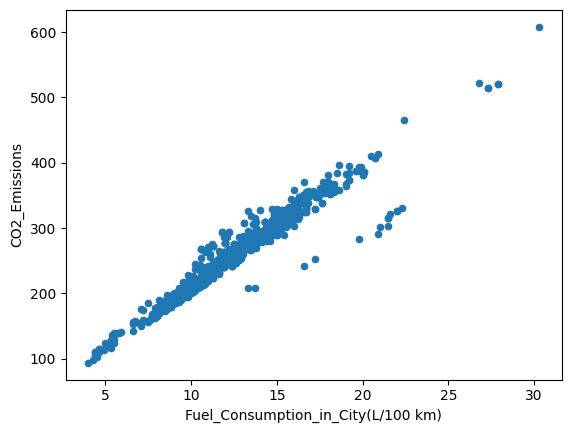

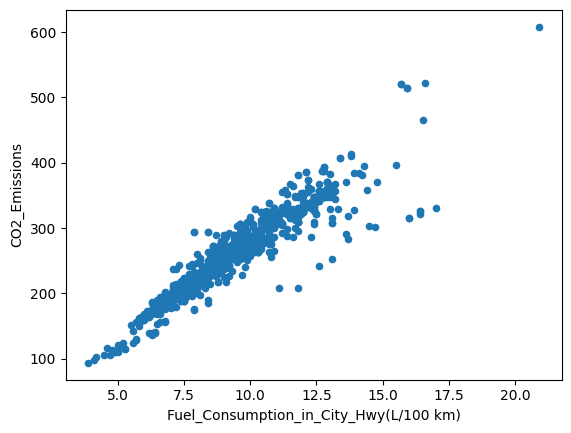

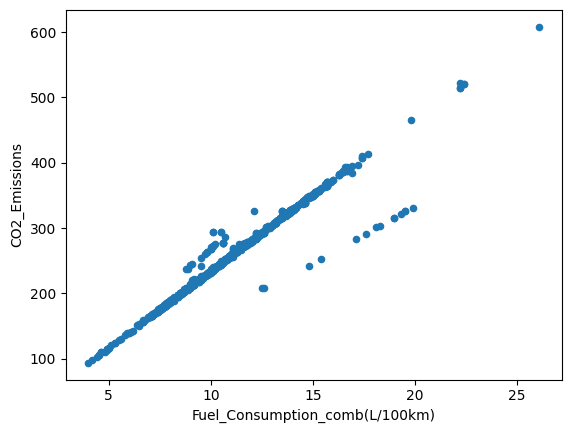

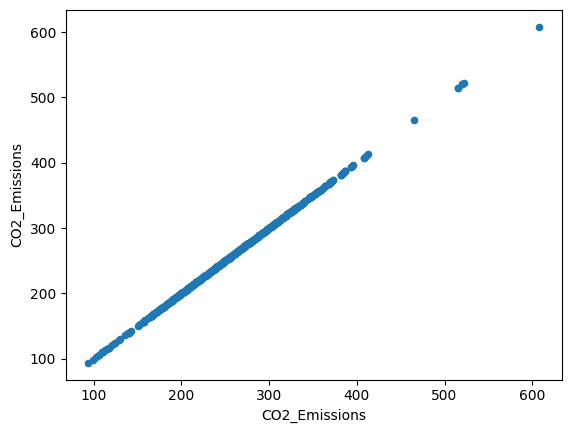

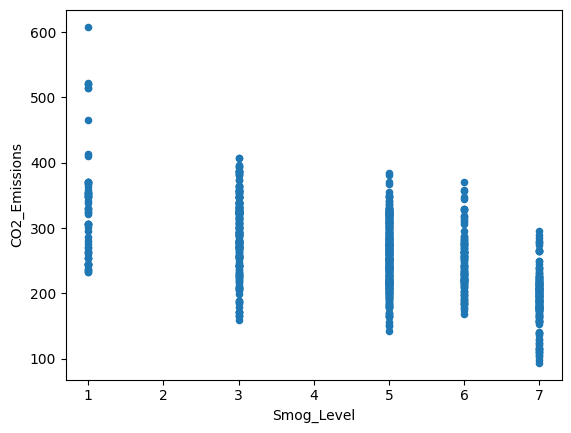

In [36]:
for column in data.columns:
  ax = data.plot(kind='scatter',x=column,y='CO2_Emissions')
  ax.tick_params(axis='x',labelleft = False)

/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])
/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])


array([[<Axes: xlabel='Model_Year', ylabel='Model_Year'>,
        <Axes: xlabel='Engine_Size', ylabel='Model_Year'>,
        <Axes: xlabel='Cylinders', ylabel='Model_Year'>,
        <Axes: xlabel='Fuel_Consumption_in_City(L/100 km)', ylabel='Model_Year'>,
        <Axes: xlabel='Fuel_Consumption_in_City_Hwy(L/100 km)', ylabel='Model_Year'>,
        <Axes: xlabel='Fuel_Consumption_comb(L/100km)', ylabel='Model_Year'>,
        <Axes: xlabel='CO2_Emissions', ylabel='Model_Year'>,
        <Axes: xlabel='Smog_Level', ylabel='Model_Year'>],
       [<Axes: xlabel='Model_Year', ylabel='Engine_Size'>,
        <Axes: xlabel='Engine_Size', ylabel='Engine_Size'>,
        <Axes: xlabel='Cylinders', ylabel='Engine_Size'>,
        <Axes: xlabel='Fuel_Consumption_in_City(L/100 km)', ylabel='Engine_Size'>,
        <Axes: xlabel='Fuel_Consumption_in_City_Hwy(L/100 km)', ylabel='Engine_Size'>,
        <Axes: xlabel='Fuel_Consumption_comb(L/100km)', ylabel='Engine_Size'>,
        <Axes: xlabel='CO2_Emissio

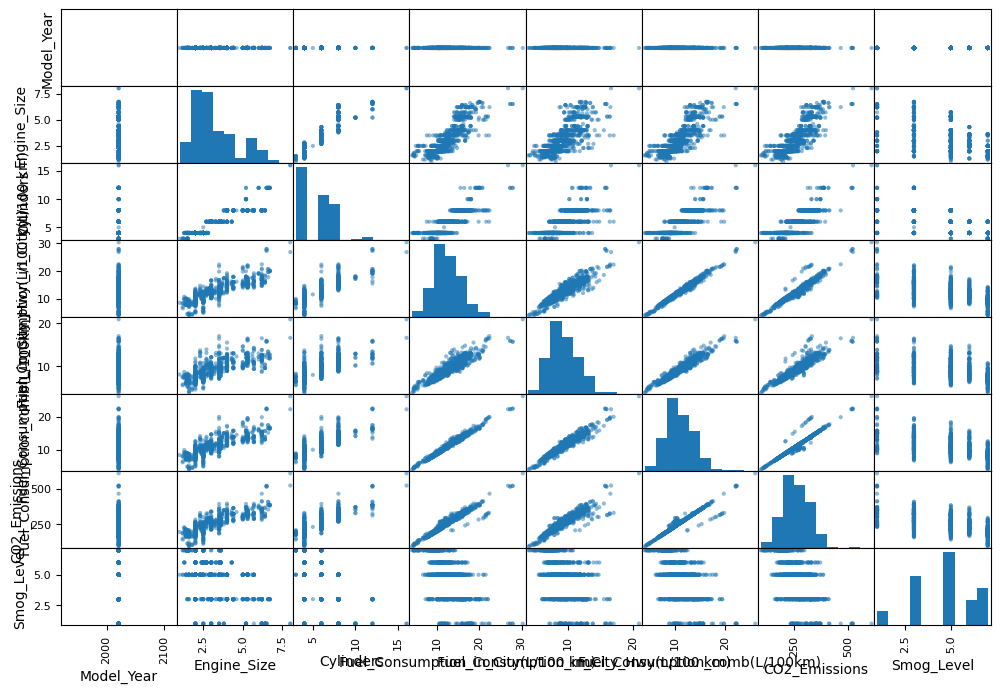

In [37]:
from pandas.plotting import scatter_matrix
attributes = data.columns
scatter_matrix(data[attributes], figsize=(12, 8))

In [38]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix['CO2_Emissions'].sort_values(ascending=False)

,CO2_Emissions
CO2_Emissions,1.000000
Fuel_Consumption_comb(L/100km),0.971241
Fuel_Consumption_in_City(L/100 km),0.966137
Fuel_Consumption_in_City_Hwy(L/100 km),0.933468
Cylinders,0.834972
Engine_Size,0.825725
Smog_Level,-0.583690
Model_Year,NaN


##Feature Engineering

In [39]:
data['Consumption_per_Cylinder'] = data['Fuel_Consumption_comb(L/100km)']/data['Cylinders']

data['Engine_Efficiency'] = data['Fuel_Consumption_comb(L/100km)']/data['Engine_Size']

display(data.head())

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level,Consumption_per_Cylinder,Engine_Efficiency
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3,2.150000,3.583333
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3,1.833333,3.142857
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6,2.475000,4.950000
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6,2.575000,5.150000
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7,2.450000,4.900000


In [40]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix['CO2_Emissions'].sort_values(ascending=False)

,CO2_Emissions
CO2_Emissions,1.000000
Fuel_Consumption_comb(L/100km),0.971241
Fuel_Consumption_in_City(L/100 km),0.966137
Fuel_Consumption_in_City_Hwy(L/100 km),0.933468
Cylinders,0.834972
Engine_Size,0.825725
Consumption_per_Cylinder,-0.086073
Engine_Efficiency,-0.343022
Smog_Level,-0.583690
Model_Year,NaN


##Selección de atributos

In [41]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

features_numeric = list(data.select_dtypes(include=['float64','int']))
X = data[features_numeric]
y = data['CO2_Emissions']

selector_filter = SelectKBest(score_func=f_regression,k=6)
selector_filter.fit(X,y)

#Obtener puntuaciones
filter_scores = pd.DataFrame({
    'Atributo': features_numeric,
    'Puntuacion_F': selector_filter.scores_,
    'Seleccionado': selector_filter.get_support()
}).sort_values(by='Puntuacion_F',ascending=False)

display(filter_scores)

,Atributo,Puntuacion_F,Seleccionado
6,CO2_Emissions,8.403717e+17,True
5,Fuel_Consumption_comb(L/100km),1.552459e+04,True
3,Fuel_Consumption_in_City(L/100 km),1.308035e+04,True
4,Fuel_Consumption_in_City_Hwy(L/100 km),6.319939e+03,True
2,Cylinders,2.148016e+03,True
1,Engine_Size,1.999321e+03,True
7,Smog_Level,4.821235e+02,False
9,Engine_Efficiency,1.244203e+02,False
8,Consumption_per_Cylinder,6.963751e+00,False
0,Model_Year,0.000000e+00,False


In [42]:
estimator = RandomForestRegressor(n_estimators=50,random_state=42)

selector_wrapper =RFE(estimator,n_features_to_select=6,step=1)
selector_wrapper.fit(X,y)

wrapper_ranking = pd.DataFrame({
    'Atributo': features_numeric,
    'Seleccionado': selector_wrapper.support_,
}).sort_values(by='Seleccionado',ascending=False)

display(wrapper_ranking)

,Atributo,Seleccionado
1,Engine_Size,True
3,Fuel_Consumption_in_City(L/100 km),True
4,Fuel_Consumption_in_City_Hwy(L/100 km),True
5,Fuel_Consumption_comb(L/100km),True
6,CO2_Emissions,True
8,Consumption_per_Cylinder,True
0,Model_Year,False
2,Cylinders,False
7,Smog_Level,False
9,Engine_Efficiency,False
